# HD Integrated Visium Interactive Suite (HiVis) - Analyses
This Notebook describes the various analysis methods available in both bin and aggregation levels. 


We will use the HiVis object from [previous notebook](https://github.com/roynov01/HiVis/blob/main/tutorials/4_plotting.ipynb).

To see a details explanation and parameters for each function, visit the [documentation](https://hivis.readthedocs.io/en/latest/).

****
All analyses are available for both HiVis and Agg objects.

Most analyses can accept a "layer" argument, where the data will be taken from.

In [ ]:
import os
import sys
import matplotlib.pyplot as plt
from HiVis import HiVis

sys.path.append(os.path.abspath(".."))

path = 'output/mouse_intestine.pkl'
si = HiVis.load(path) 
sub = HiVis.load('output/mouse_intestine_subset.pkl') 

## Pseudobulk
Aggregates expression based on an OBS into an expression-matrix (for example genes by celltypes).

In [2]:
pb = si.analysis.pseudobulk(by="intestine_part")
pb.head()

,proximal,distal
Lypla1,0.000254,0.000175
Tcea1,0.000135,0.000132
Atp6v1h,0.000146,0.000163
Cops5,0.000110,0.000106
Arfgef1,0.000303,0.000317


If "by" is not specified, we get the mean expression level across al bins/cells

In [5]:
pb = sub.agg["SC"].analysis.pseudobulk()
pb.head()

Lypla1     0.000290
Tcea1      0.000139
Atp6v1h    0.000145
Cops5      0.000117
Arfgef1    0.000296
dtype: float32

## Differential gene expression analysis (DGE)
Performs statistical test to find genes that are differentially expressed between groups. This analysis can take few minutes, depending on the size of the dataset.

### One to one
To find which genes are higher in one group in comparsison to an other. For example, genes that are different between two celltypes. 

In [6]:
proximal_distal = si.analysis.dge("intestine_part",group1="proximal",group2="distal",method="wilcox",inplace=False)
proximal_distal.loc[(proximal_distal["qval"] == 0) & (abs(proximal_distal["log2fc"]) > 4)]

Normalizing "proximal" spots
Normalizing "distal" spots


Running wilcox on [intestine_part]: 100%|██████████████████████████████████████████| 3222/3222 [05:30<00:00,  9.76it/s]


,log2fc,proximal,distal,pval_proximal,pval_distal,pval,qval,expression_mean,expression_min,expression_max,gene
Lct,6.516181,0.000955,0.000004,0.0,1.0,0.0,0.0,0.000480,0.000004,0.000955,Lct
Fam151a,4.742261,0.000276,0.000004,0.0,1.0,0.0,0.0,0.000140,0.000004,0.000276,Fam151a
Saa1,-5.024337,0.000016,0.000714,1.0,0.0,0.0,0.0,0.000365,0.000016,0.000714,Saa1
Apoa4,4.867053,0.002391,0.000076,0.0,1.0,0.0,0.0,0.001233,0.000076,0.002391,Apoa4
Enpp7,5.511146,0.001252,0.000021,0.0,1.0,0.0,0.0,0.000637,0.000021,0.001252,Enpp7
Asah2,4.005915,0.000689,0.000037,0.0,1.0,0.0,0.0,0.000363,0.000037,0.000689,Asah2


Lets visualise the top differentialy expressed genes between the groups

<Axes: >

<Figure size 640x480 with 0 Axes>

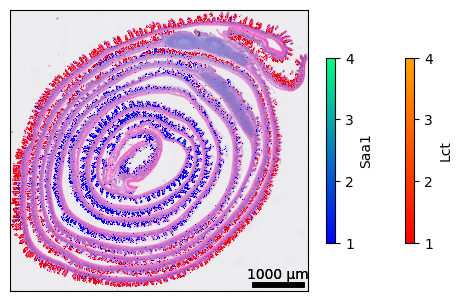

In [7]:
ax = si.plot.spatial("Lct", cmap=["red","orange"],figsize=(6,4),image=False,axis_labels=False,title="")
si.plot.spatial("Saa1", cmap="winter", ax=ax, title="",axis_labels=False)

### One to all
To find which genes are higher in one group in comparsison to all other groups. For example, genes that are specific to a celltype.

In [9]:
clust = sub.agg["SC"].analysis.dge("leiden",group1="4")
clust.loc[[clust['log2fc'].idxmin(), clust['log2fc'].idxmax()]]

Normalizing "4" spots
Normalizing "rest" spots


Running wilcox on [leiden]: 100%|████████████████████████████████████████████████| 3222/3222 [00:02<00:00, 1291.76it/s]


,log2fc,4,rest,pval_4,pval_rest,pval,qval,expression_mean,expression_min,expression_max,gene
Enpp7,-9.763212,0.000000,0.001471,1.0,0.0,0.0,0.0,0.000735,0.000000,0.001471,Enpp7
Defa26,6.577621,0.001617,0.000015,0.0,1.0,0.0,0.0,0.000816,0.000015,0.001617,Defa26


<Axes: >

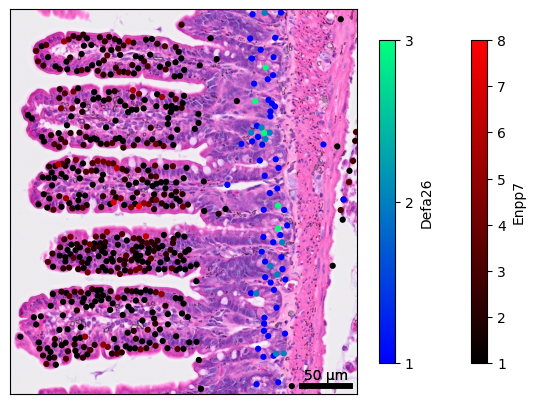

In [51]:
ax = sub.agg["SC"].plot.spatial("Enpp7",size=20,cmap=["black","red"],alpha=1)
sub.agg["SC"].plot.spatial("Defa26",size=20,ax=ax,alpha=1,title="")

## Correlation analysis
For details on plotting the results visit notebook #4.

### Correlation of a single value
Performs spearman correlation on a gene or obs, with all genes. Good for exploring gene-grous that expressed together.

Ruuning it on fullsize bin-level data takes a long time, so it's recommended to work with single-cell level or crop the HiVis object (detail in notebook #1).

In [18]:
gene = "Iglc1"
cor_iglc1 = sub.agg["SC"].analysis.cor("Iglc1",inplace=True)
cor_iglc1.head()

Computing correlation with Iglc1: 100%|██████████████████████████████████████████| 3222/3222 [00:00<00:00, 3802.40it/s]


,r,expression_mean,gene,pval,qval
0,0.051778,0.000212,Lypla1,0.009401,0.046744
1,0.010949,0.000128,Tcea1,0.583108,0.758181
2,-0.019071,0.000189,Atp6v1h,0.339074,0.544886
3,0.020406,0.000126,Cops5,0.306329,0.514326
4,-0.000162,0.000277,Arfgef1,0.993529,0.997921


<Axes: title={'center': 'Iglc1'}, xlabel='log10(mean expression)', ylabel='Spearman correlation'>

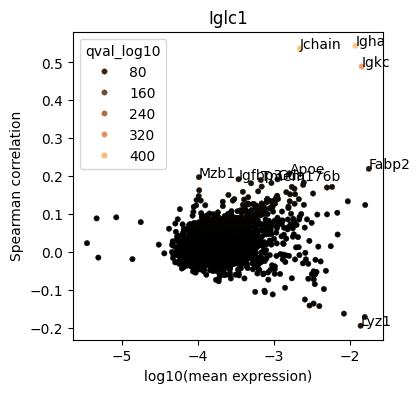

In [20]:
sub.agg["SC"].plot.cor(gene,figsize=(4,4))

### Correlation matrix
Performs spearman correlation between a list of genes/obs. 

In [22]:
genes = ["Iglc1","Ang4","Defa21","Igkc","Jchain","Lyz1","Itln1"]
cor_matrix = sub.agg["SC"].analysis.cor(genes)
cor_matrix

,Iglc1,Ang4,Defa21,Igkc,Jchain,Lyz1,Itln1
Iglc1,1.000000,-0.136923,-0.175935,0.353658,0.470988,-0.194684,-0.161925
Ang4,-0.136923,1.000000,0.550183,-0.068227,-0.057770,0.524953,0.552328
Defa21,-0.175935,0.550183,1.000000,-0.121643,-0.097076,0.562004,0.536045
Igkc,0.353658,-0.068227,-0.121643,1.000000,0.453353,-0.143443,-0.099055
Jchain,0.470988,-0.057770,-0.097076,0.453353,1.000000,-0.104791,-0.101661
Lyz1,-0.194684,0.524953,0.562004,-0.143443,-0.104791,1.000000,0.521035
Itln1,-0.161925,0.552328,0.536045,-0.099055,-0.101661,0.521035,1.000000


<Axes: >

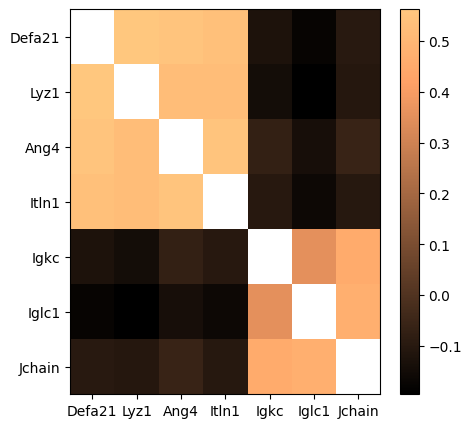

In [24]:
sub.agg["SC"].plot.cor(genes,figsize=(5,5),cluster=True)

## Score genes
Works for both HiVis and Agg objects. Assigns score for each bin/object, based on a list of genes.

In [30]:
muscle_genes = ["Tpm2","Tpm1","Acta1","Myh11","Tagln","Des","Actg"]
sub.agg["SC"].analysis.score_genes(muscle_genes, "muscle_score",z_normalize=True)

Cell_ID_SC
00051825-5b90-4a91-8f0e-00f630ed5a92    0.683403
00085c90-58ff-434f-ba5a-8665ff1811ee    0.074742
000e9178-d506-4064-9f77-ff0b994add6e   -0.959742
001e8a45-e8cb-4b0d-9f12-fa7cacd6a513   -0.033518
0022cdd9-9147-47ac-a682-a032fd356625    0.014597
                                          ...   
ff5b292b-cf36-4f08-914b-7ddc8edadc19    0.719490
ff79548d-2e34-4f72-babd-e4075277b1da    0.062713
ffef2b14-f6d8-41d4-8212-53000de46473   -0.538731
fff4e317-c285-44e3-90a3-25318678b853    2.213476
fffc7dda-4ca6-436d-8e4f-7d743a6c0962   -0.671049
Name: muscle_score, Length: 2515, dtype: float64

<Axes: title={'center': 'muscle_score'}>

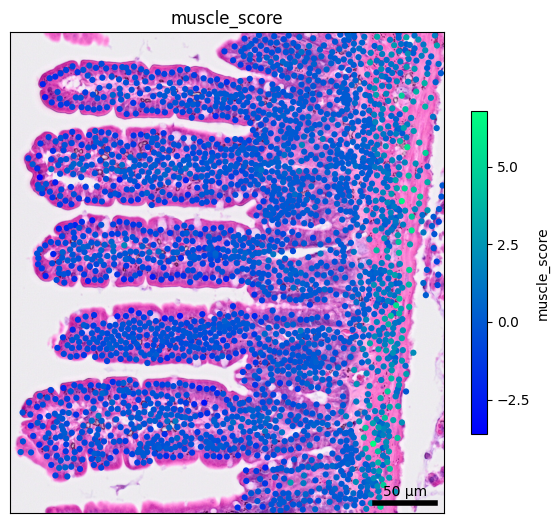

In [31]:
xlim = [0,350]
ylim = [3400,3750]
sub.agg["SC"].plot.spatial("muscle_score",size=20)

## Smoothing
Since the data is sparse, in some cases we want to smooth the data spatially. This analysis smooths the values in specific radius. Notice that on bin-level data, since lots of values are 0, some filters may yiels only zeroes.

In [33]:
sub.agg["SC"].analysis.smooth("muscle_score", radius=40, method="mean", new_col_name="muscle_score_smoothed")

Building coordinate tree


'mean' smoothing 'muscle_score' in radius 40: 100%|█████████████████████████████| 2515/2515 [00:00<00:00, 44783.74it/s]


[np.float64(1.8709361656385597),
 np.float64(0.0020966719183155),
 np.float64(-0.5021809818680688),
 np.float64(0.09272407129163839),
 np.float64(-0.67420635121537),
 np.float64(-0.5398753240074263),
 np.float64(0.5930040426468013),
 np.float64(0.042402971493198605),
 np.float64(-0.6046700595008478),
 np.float64(0.5049442656493404),
 np.float64(-0.2932637675465013),
 np.float64(0.5687660284086963),
 np.float64(-0.23240231684952),
 np.float64(-0.44279513827742334),
 np.float64(-0.5193313488572142),
 np.float64(-0.21158821441030476),
 np.float64(0.04974832489758982),
 np.float64(-0.405705875521869),
 np.float64(-0.6112616745777382),
 np.float64(-0.4997231809934336),
 np.float64(-0.6202212938885694),
 np.float64(-0.4488741555342985),
 np.float64(1.617421195296641),
 np.float64(1.4579090605012688),
 np.float64(0.8361134225975033),
 np.float64(0.31353114203014293),
 np.float64(1.164427250783583),
 np.float64(-0.037485660515028156),
 np.float64(-0.43992646993683965),
 np.float64(1.2106762634

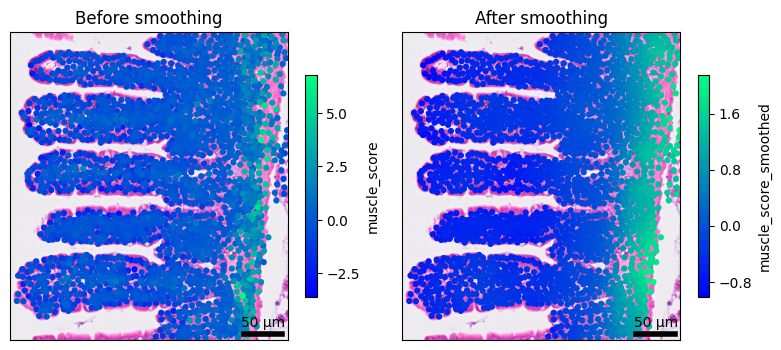

In [34]:
xlim = [0,450]
ylim = [3400,3850]

fig, axes = plt.subplots(1,2, figsize=(8,4))
sub.agg["SC"].plot.spatial("muscle_score",ax=axes[0],title="Before smoothing",size=20,axis_labels=False)
sub.agg["SC"].plot.spatial("muscle_score_smoothed", ax=axes[1],title="After smoothing",size=20,axis_labels=False)
plt.tight_layout()

## Noise-mean curve
This analysis help identify highly variable genes. It calculates the residual of each gene from linear model of the log10(CV),log10(expression).

Genes that have high residuals are "patchy", or non uniformally distributed.

In [35]:
hvg = si.analysis.noise_mean_curve(inplace=True)
hvg.head()

,gene,expression_mean,mean_log,cv,cv_log10,residual
0,Lypla1,0.003948,-2.403607,10.756030,1.129223,-0.000404
1,Tcea1,0.003009,-2.521596,11.158473,1.142012,-0.000971
2,Atp6v1h,0.003348,-2.475274,11.013533,1.137450,-0.001007
3,Cops5,0.002358,-2.627372,11.383466,1.149002,-0.000432
4,Arfgef1,0.006436,-2.191412,9.641993,1.091719,-0.000957


<Axes: xlabel='log10(mean expression)', ylabel='log10(CV)'>

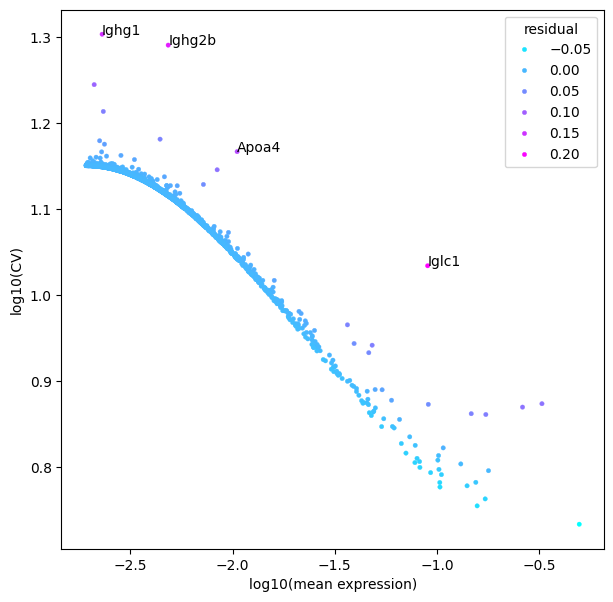

In [36]:
si.plot.noise_mean_curve()

## Calculate distances
We can calculate the distance (in µm) of bins or objects from other objects.

This calculation can take 10+ minutes for all bins, so its advisible to run it on cells or on a subset of bins.

In [37]:
si.analysis.compute_distances("intestine_part")
#si.agg["SC"].analysis.compute_distances("intestine_part")


Computing distance to intestine_part: 100%|███████████████████████████████| 5201556/5201556 [04:28<00:00, 19383.05it/s]


We can plot the distance, or the closest object

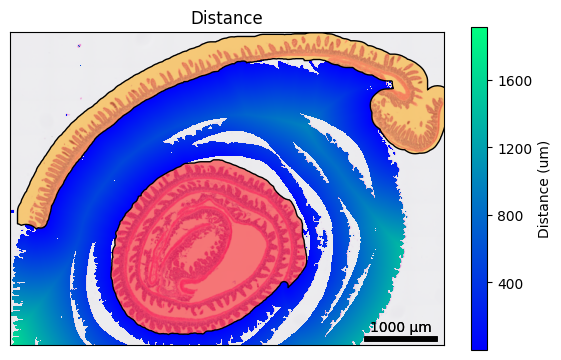

In [46]:
ax = si.agg["intestine_part"].plot.cells("intestine_part_col", ylim=[0,4600] ,alpha=0.5,cmap=["red","orange"],legend=False)
si.plot.spatial("dist_to_intestine_part", ylim=[0,4600],title="Distance",ax=ax,legend_title="Distance (um)")

<Axes: title={'center': 'Intestinal part'}>

<Figure size 640x480 with 0 Axes>

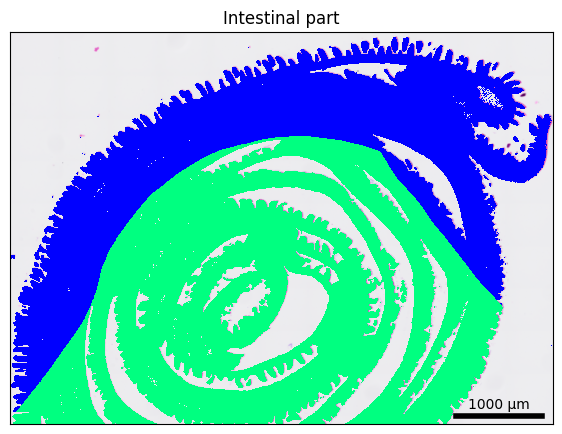

In [50]:
si.plot.spatial("nearest_intestine_part", ylim=[0,4600],title="Intestinal part",legend=False)